In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
# Parámetros base
N  = 100_000
S0 = 99_999.0
I0 = 1.0
R0 = 0.0
beta  = 0.4
gamma = 0.1
days  = 180
t = np.linspace(0, days, days*4+1)  # pasos de 6 horas

In [17]:
def sir_deriv(t, y, beta, gamma, N):
    S, I, R = y
    dS = -beta * S * I / N
    dI =  beta * S * I / N - gamma * I
    dR =  gamma * I
    return np.array([dS, dI, dR], dtype=float)

def rk4(func, y0, t, args):
    y = np.zeros((t.size, len(y0)), dtype=float)
    y[0] = y0
    for k in range(t.size - 1):
        h = t[k+1] - t[k]
        k1 = func(t[k],         y[k],            *args)
        k2 = func(t[k] + h/2.0, y[k] + h*k1/2.0, *args)
        k3 = func(t[k] + h/2.0, y[k] + h*k2/2.0, *args)
        k4 = func(t[k] + h,     y[k] + h*k3,     *args)
        y[k+1] = y[k] + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    return y

def simulate(N, S0, I0, R0, beta, gamma, t):
    y0 = np.array([S0, I0, R0], dtype=float)
    Y  = rk4(sir_deriv, y0, t, (beta, gamma, N))
    return Y[:,0], Y[:,1], Y[:,2]

def metrics(t, I, R, N):
    i_peak_idx = int(np.argmax(I))
    t_peak = t[i_peak_idx]
    I_peak = I[i_peak_idx]
    extinct_idx = np.where(I < 1.0)[0]
    t_extinct = t[extinct_idx[0]] if extinct_idx.size > 0 else t[-1]
    final_infected_pct = (R[-1] / N) * 100.0
    return t_peak, I_peak, t_extinct, final_infected_pct



In [18]:
# Escenario base
S_b, I_b, R_b = simulate(N, S0, I0, R0, beta, gamma, t)
t_peak_b, I_peak_b, t_ext_b, pct_inf_b = metrics(t, I_b, R_b, N)
R0_basic = beta / gamma

print("Baseline")
print(f"R0 = {R0_basic:.2f}")
print(f"Pico de infectados: día {t_peak_b:.1f}, I_max = {I_peak_b:.0f} personas")
print(f"Fin de la epidemia (I<1): día {t_ext_b:.1f}")
print(f"% de población infectada al final: {pct_inf_b:.2f}%")

Baseline
R0 = 4.00
Pico de infectados: día 42.5, I_max = 40343 personas
Fin de la epidemia (I<1): día 164.2
% de población infectada al final: 98.02%


In [19]:
# Cuarentena (reduce beta 40%)
beta_q = beta * 0.60
S_q, I_q, R_q = simulate(N, S0, I0, R0, beta_q, gamma, t)
t_peak_q, I_peak_q, t_ext_q, pct_inf_q = metrics(t, I_q, R_q, N)

print("\nCuarentena (β reducido 40%)")
print(f"R0 = {beta_q/gamma:.2f}")
print(f"Pico de infectados: día {t_peak_q:.1f}, I_max = {I_peak_q:.0f} personas")
print(f"Fin de la epidemia (I<1): día {t_ext_q:.1f}")
print(f"% de población infectada al final: {pct_inf_q:.2f}%")


Cuarentena (β reducido 40%)
R0 = 2.40
Pico de infectados: día 84.5, I_max = 21856 personas
Fin de la epidemia (I<1): día 180.0
% de población infectada al final: 87.77%


In [20]:
# Vacunación inicial 20%
v = 0.20
S0_v = S0 * (1.0 - v)
R0_v = R0 + S0 * v
S_v, I_v, R_v = simulate(N, S0_v, I0, R0_v, beta, gamma, t)
t_peak_v, I_peak_v, t_ext_v, pct_inf_v = metrics(t, I_v, R_v, N)

print("\nVacunación inicial 20%")
print(f"R0 (efectivo inicial) = {beta/gamma:.2f} con S(0) reducido")
print(f"Pico de infectados: día {t_peak_v:.1f}, I_max = {I_peak_v:.0f} personas")
print(f"Fin de la epidemia (I<1): día {t_ext_v:.1f}")
print(f"% de población infectada al final: {pct_inf_v:.2f}%")


Vacunación inicial 20%
R0 (efectivo inicial) = 4.00 con S(0) reducido
Pico de infectados: día 55.2, I_max = 25921 personas
Fin de la epidemia (I<1): día 180.0
% de población infectada al final: 96.20%


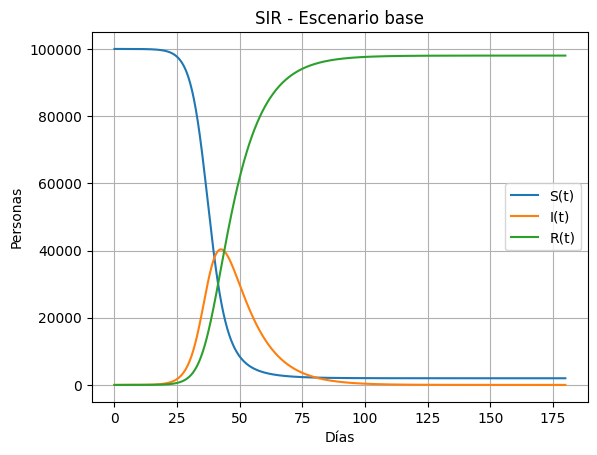

In [21]:
# Gráficas (figuras separadas, sin seaborn, sin colores específicos)
plt.figure()
plt.plot(t, S_b, label="S(t)")
plt.plot(t, I_b, label="I(t)")
plt.plot(t, R_b, label="R(t)")
plt.xlabel("Días"); plt.ylabel("Personas")
plt.title("SIR - Escenario base")
plt.legend(); plt.grid(True)
plt.show()


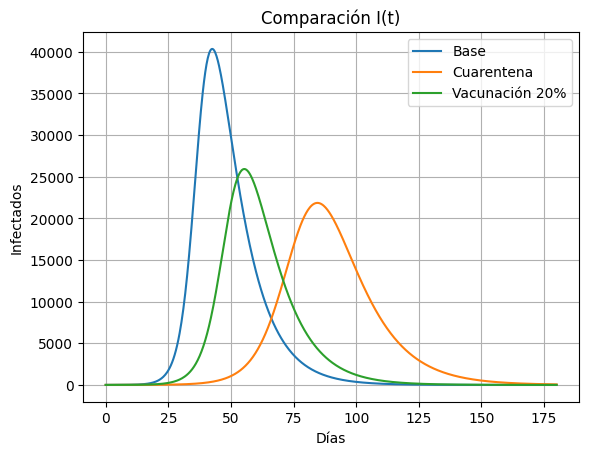

In [22]:
plt.figure()
plt.plot(t, I_b, label="Base")
plt.plot(t, I_q, label="Cuarentena")
plt.plot(t, I_v, label="Vacunación 20%")
plt.xlabel("Días"); plt.ylabel("Infectados")
plt.title("Comparación I(t)")
plt.legend(); plt.grid(True)
plt.show()